In [81]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [82]:
import idna #implementacion de tecnicas de codificacion de strings (codificacion y decodificacion de caracterers unicode)

# def utf8_to_punycode(text: str) -> str:
#     """Encodes a UTF-8 string to its Punycode representation."""
#     return idna.encode(text).decode('ascii')

def punyencode(text: str) -> str:
    """Encodes a UTF-8 string to its Punycode representation, handling spaces by encoding each word separately."""
    
    return " ".join([idna.encode(word).decode('ascii') for word in text.split()])
    
def punydecode(punycode: str) -> str:
    """Decodes a Punycode string back to UTF-8."""
    #return idna.decode(punycode)
    return " ".join([idna.decode(word) for word in punycode.split()])

def process_name(name):
    name = name.lower()
    for n in name.split():
        if len(n) < 2:
            return ''
    try:
        return punyencode(name)
    except:
        #print(f'Cant convert {name}')
        return ''

dataset = open("city_names_full.txt", 'r', encoding='utf-8').read().split('\n')
with open('city_names_puny.txt', 'w', encoding='utf-8') as f:
    for n in dataset:
        name = process_name(n)
        if name != '':
            f.write(name + '\n')
dataset = open('city_names_puny.txt', 'r', encoding='utf-8').read().split('\n')
puny = [x for x in dataset if 'xn--' in x] #filtrar todos los que tienen caracteres raros
nopuny = [x for x in dataset if 'xn--' not in x]
np.random.seed(42)
dataset = [x.item() for x in np.random.choice(nopuny, 100000, replace=False)]

In [83]:
charset = ['*'] + sorted(list(set([y for x in dataset for y in x])))
ctoi = {c:i for i, c in enumerate(charset)}
itoc = {i:c for i, c in enumerate(charset)}
charset_size = len(charset)

In [84]:
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.W1 = torch.randn(self.emb_size*self.context_size, self.hidden_size, generator=g) * (5/3 / (self.emb_size*self.context_size)**0.5) #inicializacion kaiming
        self.b1 = torch.randn(self.hidden_size, generator=g) #no garantiza que no mueran capaz durante el entrenamiento, solo la init
        self.W2 = torch.randn(self.hidden_size, self.charset_size, generator=g)
        self.b2 = torch.randn(self.charset_size, generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]
        for p in self.parameters:
            p.requires_grad = True
    
    def __call__(self, x):
        self.emb = self.C[x]
        self.embcat = self.emb.view(-1, self.emb_size*self.context_size)
        self.preact = self.embcat @ self.W1 + self.b1
        self.act = torch.tanh(self.preact)
        self.logits = self.act @ self.W2 + self.b2
        return self.logits

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters])

    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    def requieres_grad(self):
        for p in self.parameters:
            p.requieres_grad = True
 
    def sample(self, nsamples, g=torch.Generator().manual_seed(42)):
        samples = []
        for n in range(nsamples):
            context = [0] * context_size
            out = []
            while True:
                logits = self(torch.tensor(context))
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                    samples.append(''.join(out[:-1]))
                    break
        return samples

def nll(logits, Y):
    return F.cross_entropy(logits, Y)

In [85]:
def build_dataset(dataset: list):
    X, Y  = [], []
    for d in dataset:
        example = list(d) + ['*']
        context = [0] * context_size
        for c in example:
            X.append(context)
            Y.append(ctoi[c])
            context = context[1:] + [ctoi[c]] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# build the dataset
context_size = 3
np.random.seed(42)
np.random.shuffle(dataset)
n1 = int(.8 * len(dataset))  # límite para el 80% del dataset
n2 = int(.9 * len(dataset))  # límite para el 90% del dataset
Xtr, Ytr = build_dataset(dataset[:n1])    # 80%
Xva, Yva = build_dataset(dataset[n1:n2])  # 10%
Xte, Yte = build_dataset(dataset[n2:])    # 10%

In [86]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

18616

In [87]:
batch_size = 32

steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters:
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    lr = 0.1 if i < 100000 else 0.01 # learing rate decay
    for p in model.parameters:
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')

epoch 0/200000 loss: 34.3794
epoch 10000/200000 loss: 3.2703
epoch 20000/200000 loss: 2.7041
epoch 30000/200000 loss: 2.4271
epoch 40000/200000 loss: 2.5932
epoch 50000/200000 loss: 2.6064
epoch 60000/200000 loss: 3.5411
epoch 70000/200000 loss: 2.7299
epoch 80000/200000 loss: 2.2601
epoch 90000/200000 loss: 2.5488
epoch 100000/200000 loss: 2.7437
epoch 110000/200000 loss: 2.2090


KeyboardInterrupt: 

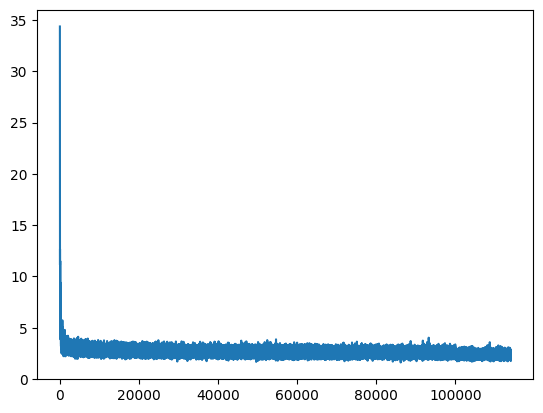

In [88]:
plt.plot(losses)

In [89]:
model.sample(10)

['kisan fastat',
 'chan',
 'moith bampa',
 'bachnustreke ost',
 'molo',
 'aumbalfor',
 'shniberg',
 'linguan gao',
 'cen',
 'uspezentinasanobelle']

In [90]:
#inicializacion de la red
#mayor lr = mas neuronas muertas

In [91]:
# Arreglando la saturación de la tanh con Kaiming Init

# De donde vienen esos números mágicos que multiplican a los pesos Ws y bs?

#pytorcheando

class Linear:
    def __init__ (self, input_dim, output_dim, bias=True, generator=torch.Generator().manual_seed(42)):
        self.W = torch.randn(input_dim, output_dim, generator=generator)/(input_dim**0.5)
        self.b = torch.zeros(output_dim) if bias else None
    
    def __call__(self,X):
        self.out = X @ self.W
        if self.b is not None:
            self.out += self.b
        return self.out
    
    def parameters(self):
        return [self.W] + ([] if self.b is None else [self.b])

class Tanh:
        def __call__(self, X):
             self.out = torch.tanh(X)
             return self.out
        
        def parameters(self):
             return[]
        
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
          self.charset_size = charset_size
          self.context_size = context_size
          self.emb_size = emb_size
          self.hidden_size = hidden_size
          self.C = torch.randn(self.charset_size, self.emb_size, generator = g)
          self.layers = [Linear(self.emb_size*self.context_size, self.hidden_size, generator=g), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.charset_size)]
          for l in self.layers[:-1]:
                if isinstance(l, Linear):
                    l.W *= 5/3
                self.layers[-1].W*= 0.1 # La ultima capa es menos confianzuda
    
          for p in self.parameters():
                p.requires_grad = True
    
    def parameters(self):
        return [self.C] + [p for l in self.layers for p in l.parameters()]
    
    def __call__(self, X):
        self.emb = self.C[X]
        X = self.emb.view(-1, self.emb_size*self.context_size)
        for l in self.layers:
            X = l(X)
        return X
    
    def count_parameters(self):
         return sum([p.nelement() for p in self.parameters()])
    
    def to(self, device):
         for p in self.parameters():
              p.to(device)



In [92]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

281784

In [93]:
model.to('cpu')

In [94]:
batch_size = 32
lr= 0.1
steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters():
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    if i < 100000 and i< 200000: # learing rate decay
        lr= 0.1
    if i> 200000:
        lr= 0.1
    for p in model.parameters():
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')

epoch 0/200000 loss: 3.6889


KeyboardInterrupt: 

In [95]:
#modelo sin pytorch

class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.W1 = torch.randn(self.emb_size*self.context_size, self.hidden_size, generator=g) * (5/3 / (self.emb_size*self.context_size)**0.5)
        self.b1 = torch.randn(self.hidden_size, generator=g) * 0.0
        self.W2 = torch.randn(self.hidden_size, self.charset_size, generator=g) * 0.001
        self.b2 = torch.randn(self.charset_size, generator=g) * 0.0
        self.gamma = torch.ones(hidden_size)
        self.beta = torch.zeros(hidden_size)
        self.running_mean = torch.zeros(hidden_size)
        self.running_std = torch.ones(hidden_size)
        self.momentum = 0.01
        self.training_mode_on = True
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2, self.gamma, self.beta ]
        for p in self.parameters:
            p.requires_grad = True
    
    def __call__(self, X):
        self.emb = self.C[X]
        self.embcat = self.emb.view(-1, self.emb_size * self.context_size)
        self.preact = self.embcat @ self.W1 + self.b1
        if self.training_mode_on:
            with torch.no_grad():
                xmean = self.preact.mean(axis=0, keepdims=True)
                xstd = self.preact.std(axis=0, keepdims=True)
                self.running_mean = self.running_mean * (1-self.momentum) + xmean * (self.momentum)
                self.running_std = self.running_std * (1-self.momentum) + xstd * (self.momentum)
        self.preact = self.gamma *((model.preact - self.running_mean) / self.running_std) + self.beta #normalizacion?
        act = torch.tanh(self.preact)
        self.logits = act @ self.W2 + self.b2
        return self.logits

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters])
    
    def calibrate(self, x):
        with torch.no_grad():
            self.emb = self.C[x]
            self.embcat = self.emb.view(-1,self.emb_size * self.context_size)
            self.preact = self.embcat @ self.W1 + self.b1
            self. bnmean = self.preact.mean(axis=0, keepdims=True)
            self.bnstd = self.preact.std(axis=0, keepdims=True) + 0.0005
        
    
    def sample(self, nsamples, g=torch.Generator().manual_seed(42)):
        self.trainin_mode_on = False
        samples = []
        for n in range(nsamples):
            context = [0] * context_size
            out = []
            while True:
                logits = self(torch.tensor(context))
                # counts = logits.exp()
                # probs = counts / counts. sum(1, keepdims=True)
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                    samples.append(''.join(out[:-1]))
                    break
        self.trainin_mode_on = True
        return samples


def nll(logits, Y): 
    return F.cross_entropy(logits,  Y)
    #esto es reemplazado de ahora en adelante por F.cross_Entropy(hace lo mismo)
    # counts = logits.exp()
    # probs = counts / counts. sum(1, keepdims=True)
    # return -(probs[torch.arange(len(Y)), Y]).log().mean()

In [96]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

19128

In [97]:
model.calibrate(Xtr)

KeyboardInterrupt: 

In [ ]:
bn1, bn2 = (model.bnmean, model.bnstd)

In [ ]:
batch_size = 32

steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters:
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    lr= 0.1 if i < 100000 else 0.01 # learing rate decay
    for p in model.parameters:
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')

epoch 0/200000 loss: 3.6845
epoch 10000/200000 loss: 2.5199
epoch 20000/200000 loss: 2.3680
epoch 30000/200000 loss: 2.4372
epoch 40000/200000 loss: 2.2551
epoch 50000/200000 loss: 2.5145
epoch 60000/200000 loss: 2.4013
epoch 70000/200000 loss: 2.6402
epoch 80000/200000 loss: 2.3720
epoch 90000/200000 loss: 2.2424
epoch 100000/200000 loss: 2.0215
epoch 110000/200000 loss: 2.3630
epoch 120000/200000 loss: 2.1597
epoch 130000/200000 loss: 2.3250
epoch 140000/200000 loss: 2.5968
epoch 150000/200000 loss: 2.0541
epoch 160000/200000 loss: 2.5079
epoch 170000/200000 loss: 2.4248
epoch 180000/200000 loss: 2.3571
epoch 190000/200000 loss: 2.2565
Train loss 2.310319185256958
Vtion loss 2.326979875564575


In [98]:
model.sample(1)

C:\Users\TheCague\AppData\Local\Temp\ipykernel_19536\736851763.py:31: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  xstd = self.preact.std(axis=0, keepdims=True)


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

In [99]:

samples = []
for n in range(10):
        context = [0] * context_size
        out = []
        while True:
                logits = model(torch.tensor(context))
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                        samples.append(''.join(out[:-1]))
                        break

samples

C:\Users\TheCague\AppData\Local\Temp\ipykernel_19536\736851763.py:31: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  xstd = self.preact.std(axis=0, keepdims=True)


NameError: name 'g' is not defined

In [100]:
class Linear:
    def __init__(self, input_dim, output_dim, bias=True, generator=torch.Generator().manual_seed(42)):
        self.W = torch.randn(input_dim, output_dim, generator=generator)/(input_dim ** 0.5)
        self.b = torch. zeros(output_dim) if bias else None

    def parameters(self):
        return [self.W] + ([] if self.b is None else [self.b])

class Tanh:
    def __call__ (self, x):
        self.out = torch. tanh(x)
        return self.out

    def parameters(self):
        return []
    
class BatchNormld:
    def __init__(self, input_size, momentum=0.001, eps=0.0005):
        self.momentum = momentum
        self.eps = eps
        self.training_mode_on = True
        # los parametros
        self.gamma = torch.ones(input_size)
        self.beta = torch. zeros(input_size)
        self. running_mean = torch. zeros(input_size)
        self.runnint_std = torch. ones(input_size)

def __call__(self, x):
    if self.training_mode_on:
        xmean = x.mean(0, keepdims=True)
        xstd = x.std(0, keepdims=True)
        with torch.no_grad():
            self.running_mean = self.running_mean * (1 - self.momentum) + xmean * self.momentum
            self.runnint_std = self.runnint_std * (1 - self.momentum) + xstd * self.momentum
    else:
        xmean = self. running_mean
        xstd = self.runnint_std
    # normalizamos x para que tenga distribución N(0, 1)
    xhat = (x - xmean)/ (xstd + self.eps)
    self.out = self.gamma * xhat + self.beta
    return self.out

def parameters(self):
    return[self.gamma, self.beta]

class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.layers = [Linear(self.emb_size*self.context_size, self.hidden_size, bias=False, generator=g), BatchNormld(self.hidden_size), Tanh(),
                        Linear(self.hidden_size, self.hidden_size, bias=False), BatchNormld(self.hidden_size), Tanh(),
                        Linear(self.hidden_size, self.hidden_size, bias=False), BatchNormld(self.hidden_size), Tanh(),
                        Linear(self.hidden_size, self.hidden_size, bias=False), BatchNormld(self.hidden_size), Tanh(),
                        Linear(self.hidden_size, self.hidden_size, bias=False), BatchNormld(self.hidden_size), Tanh(),
                        Linear(self.hidden_size, self.charset_size)]

        # Kaiming init para todas las capas menos la última
        for l in self.layers[ :- 1] :
            if isinstance(l, Linear):
                l.W *= 5/3
        self.layers[-1].W *= 0.1 # La última capa es menos confianzuda
        # require grad para todos los parámetros
        for p in self.parameters():
            p.requires_grad = True

    def parameters(self):
        return [self.C] + [p for l in self.layers for p in l.parameters()]

    def to(self, device):
        for p in self.parameters():
            p.to(device)

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters()])
    
    def call (self, x):
        self.emb = self.C[x]
        x = self.emb.view(-1, self.emb_size*self.context_size)
        for l in self. layers:
            x = l(x)
        return x

In [102]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

AttributeError: 'BatchNormld' object has no attribute 'parameters'

In [ ]:
batch_size = 32

steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters:
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    lr= 0.1 if i < 100000 else 0.01 # learing rate decay
    for p in model.parameters:
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')